# Phase 9 — Évaluation finale sur le test set

## Contexte
Deux candidats retenus depuis les phases précédentes :

| Candidat | AUPRC | Coût opt (€) | Pourquoi retenu |
|---|---|---|---|
| **LR baseline** (Phase 6) | 0.7845 | 2 865 € | Meilleur AUPRC global |
| **LGB Optuna tuned** (Phase 7) | 0.755 | 2 307 € | Meilleur coût |

## Correction Phase 8
> `pipeline_final.joblib` a été sauvegardé avec le mauvais modèle (LGB+ISO).  
> Cette phase réentraîne proprement **LGB Optuna tuned** depuis `phase7_results.json`.

## Plan
1. Réentraînement propre des 2 candidats
2. Métriques complètes sur le test
3. Courbe coût vs seuil
4. Detection@k — lift curve
5. Calibration (Brier score)
6. Stabilité sur 5 seeds
7. Décision finale documentée
8. Sauvegarde du modèle définitif

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.linear_model  import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration   import calibration_curve
from sklearn.metrics        import (average_precision_score, roc_auc_score,
                                    precision_recall_curve, brier_score_loss,
                                    classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay)
import lightgbm as lgb

from src.config      import (RANDOM_SEED, SCALE_POS_WEIGHT,
                              COST_FALSE_POSITIVE, TOTAL_FRAUD_AMOUNT)
from src.cost_metric import compute_cost, optimal_threshold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement des données

In [2]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
with open(MODELS_PATH / 'phase7_results.json') as f:
    p7 = json.load(f)

FEAT_COLS    = feat_cfg['all_feat_cols']
X_all        = preprocessor.transform(train[FEAT_COLS])
y_all        = train['Class'].values
X_test       = preprocessor.transform(test[FEAT_COLS])
y_test       = test['Class'].values
amounts_test = test['Amount'].values

# Val set pour early stopping (même split que Phase 7)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)

print(f'Train  : {X_train.shape} | fraudes : {y_train.sum()}')
print(f'Val    : {X_val.shape}   | fraudes : {y_val.sum()}')
print(f'Test   : {X_test.shape}  | fraudes : {y_test.sum()}')
print(f'Montant total fraudé (test) : {amounts_test[y_test==1].sum():,.2f} €')

Train  : (168233, 35) | fraudes : 301
Val    : (42059, 35)   | fraudes : 75
Test   : (73434, 35)  | fraudes : 97
Montant total fraudé (test) : 11,596.23 €


## 2. Réentraînement propre des 2 candidats

> Correction Phase 8 : on réentraîne LGB Optuna avec ses vrais hyperparamètres  
> depuis `phase7_results.json`, early stopping sur le **val set** (pas le test).

In [3]:
# ── Candidat 1 : Logistic Regression ────────────────────────────────────
lr_final = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED
)
lr_final.fit(X_train, y_train)
scores_lr = lr_final.predict_proba(X_test)[:, 1]
print('LR entraîné.')

# ── Candidat 2 : LGB Optuna tuned ────────────────────────────────────────
best_params = p7['best_params'].copy()
best_params.update({
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_state'    : RANDOM_SEED,
    'n_jobs'          : -1,
    'verbose'         : -1
})

lgb_final = lgb.LGBMClassifier(**best_params)
lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_lgb = lgb_final.predict_proba(X_test)[:, 1]
print(f'LGB Optuna entraîné. Meilleure itération : {lgb_final.best_iteration_}')

LR entraîné.
LGB Optuna entraîné. Meilleure itération : 210


## 3. Métriques complètes sur le test

In [4]:
def full_eval(name, scores, y_true=y_test, amounts=amounts_test):
    auprc   = average_precision_score(y_true, scores)
    auc_roc = roc_auc_score(y_true, scores)
    brier   = brier_score_loss(y_true, scores)
    best_thr, best_cost, costs_df = optimal_threshold(
        y_true, scores, amounts, COST_FALSE_POSITIVE
    )
    preds = (scores >= best_thr).astype(int)
    rep   = classification_report(y_true, preds, output_dict=True)
    f_m   = rep.get('1', {})
    fraud_amount = amounts[y_true == 1].sum()
    return {
        'Modèle'          : name,
        'AUPRC'           : round(auprc,   4),
        'AUC-ROC'         : round(auc_roc, 4),
        'Brier score'     : round(brier,   4),
        'Rappel'          : round(f_m.get('recall',    0), 4),
        'Précision'       : round(f_m.get('precision', 0), 4),
        'F1'              : round(f_m.get('f1-score',  0), 4),
        'Seuil optimal'   : round(best_thr, 3),
        'Coût opt (€)'    : round(best_cost['cout_total'],    2),
        '% récupéré'      : round(best_cost['pct_recupere'],  1),
        'n_TP'            : best_cost['n_tp'],
        'n_FN'            : best_cost['n_fn'],
        'n_FP'            : best_cost['n_fp'],
    }, costs_df

res_lr,  costs_lr  = full_eval('LR (baseline P6)',    scores_lr)
res_lgb, costs_lgb = full_eval('LGB Optuna (P7)',     scores_lgb)

df_res = pd.DataFrame([res_lr, res_lgb])
print('=== Métriques finales sur le test set ===')
print(df_res.T.to_string())

=== Métriques finales sur le test set ===
                              0                1
Modèle         LR (baseline P6)  LGB Optuna (P7)
AUPRC                    0.7409            0.755
AUC-ROC                  0.9795           0.9082
Brier score              0.0472           0.0009
Rappel                   0.8144           0.7732
Précision                0.4365           0.3827
F1                       0.5683           0.5119
Seuil optimal              0.99            0.281
Coût opt (€)            2927.44          2306.85
% récupéré                 15.7             16.9
n_TP                       79.0             75.0
n_FN                       18.0             22.0
n_FP                      102.0            121.0


## 4. Courbe coût vs seuil

Visualisation clé pour l'équipe Risque : à quel seuil minimiser le coût total ?

In [5]:
# Mapping des scores pour les graphiques
all_scores_map = {
    'LR (baseline P6)' : scores_lr,
    'LGB Optuna (P7)'  : scores_lgb,
}

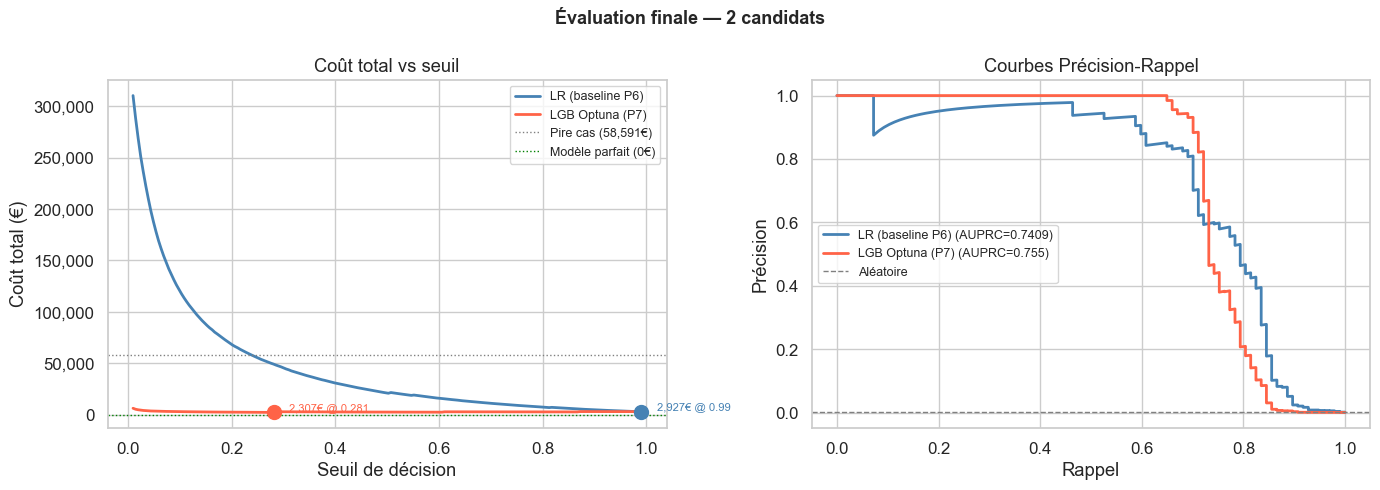

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'LR (baseline P6)': 'steelblue', 'LGB Optuna (P7)': 'tomato'}

for res, costs_df in [(res_lr, costs_lr), (res_lgb, costs_lgb)]:
    name  = res['Modèle']
    color = colors[name]
    thr   = res['Seuil optimal']
    cost  = res['Coût opt (€)']

    # Coût vs seuil
    axes[0].plot(costs_df['threshold'], costs_df['cout_total'],
                 label=f'{name}', color=color, linewidth=2)
    axes[0].scatter([thr], [cost], color=color, s=100, zorder=5)
    axes[0].annotate(f'{cost:,.0f}€ @ {thr}',
                     xy=(thr, cost), xytext=(thr+0.03, cost+500),
                     fontsize=8, color=color)

    # Courbe PR
    prec, rec, _ = precision_recall_curve(y_test,
                       all_scores_map[name])
    axes[1].plot(rec, prec,
                 label=f'{name} (AUPRC={res["AUPRC"]})',
                 color=color, linewidth=2)

# Références
axes[0].axhline(TOTAL_FRAUD_AMOUNT, color='gray', linestyle=':',
                linewidth=1, label=f'Pire cas ({TOTAL_FRAUD_AMOUNT:,.0f}€)')
axes[0].axhline(0, color='green', linestyle=':', linewidth=1,
                label='Modèle parfait (0€)')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Coût total (€)')
axes[0].set_title('Coût total vs seuil')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(fontsize=9)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label='Aléatoire')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbes Précision-Rappel')
axes[1].legend(fontsize=9)

plt.suptitle('Évaluation finale — 2 candidats', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig18_final_cost_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detection@k — Lift curve

**Question métier** : si les analystes ne peuvent traiter que N alertes par jour,  
combien de vraies fraudes capturent-ils en triant par score décroissant ?  
C'est la métrique opérationnelle principale.

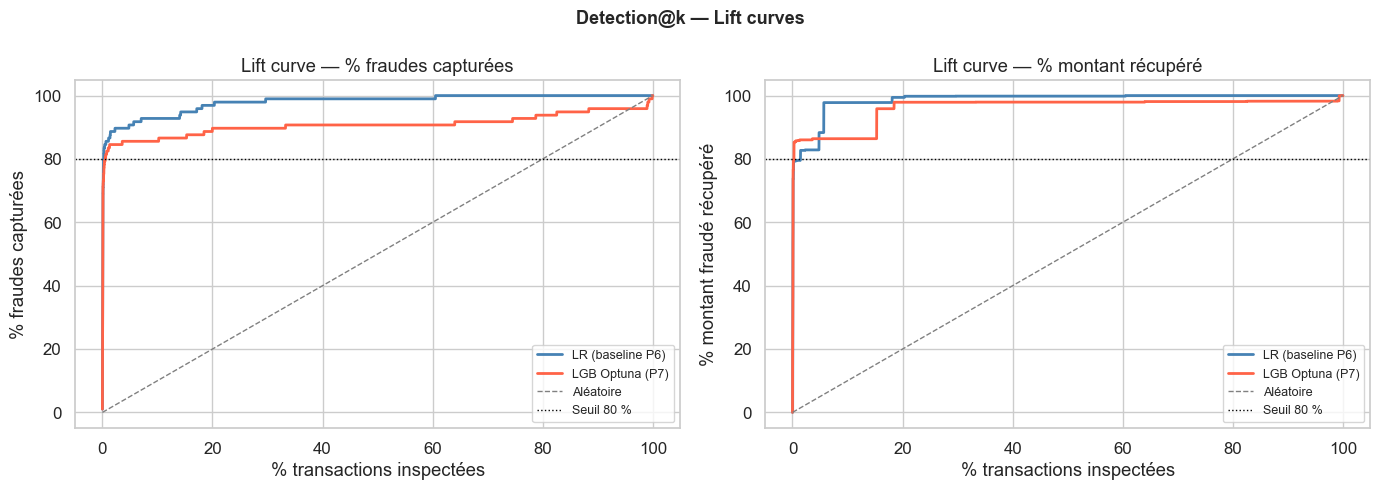

=== Detection@k : % transactions à inspecter pour capturer 80% des fraudes ===
  LR (baseline P6)          :   167 transactions (0.23%) pour 80% des fraudes
  LGB Optuna (P7)           :   372 transactions (0.51%) pour 80% des fraudes


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, scores in all_scores_map.items():
    color = colors[name]
    # Trier par score décroissant
    order      = np.argsort(scores)[::-1]
    y_sorted   = y_test[order]
    amt_sorted = amounts_test[order]

    # % fraudes capturées vs % transactions inspectées
    n_total  = len(y_test)
    n_fraud  = y_test.sum()
    cum_fraud = np.cumsum(y_sorted) / n_fraud * 100
    cum_pct   = np.arange(1, n_total + 1) / n_total * 100

    # % montant récupéré vs % transactions inspectées
    cum_amount = np.cumsum(amt_sorted * y_sorted)
    total_fraud_amount = (amounts_test * y_test).sum()
    cum_amount_pct = cum_amount / total_fraud_amount * 100

    axes[0].plot(cum_pct, cum_fraud,
                 label=name, color=color, linewidth=2)
    axes[1].plot(cum_pct, cum_amount_pct,
                 label=name, color=color, linewidth=2)

# Références
for ax in axes:
    ax.plot([0, 100], [0, 100], color='gray', linestyle='--',
            linewidth=1, label='Aléatoire')
    ax.axhline(80, color='black', linestyle=':', linewidth=1,
               label='Seuil 80 %')
    ax.set_xlabel('% transactions inspectées')
    ax.legend(fontsize=9)

axes[0].set_ylabel('% fraudes capturées')
axes[0].set_title('Lift curve — % fraudes capturées')
axes[1].set_ylabel('% montant fraudé récupéré')
axes[1].set_title('Lift curve — % montant récupéré')

plt.suptitle('Detection@k — Lift curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig19_lift_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Chiffres clés : à quel k capture-t-on 80% des fraudes ?
print('=== Detection@k : % transactions à inspecter pour capturer 80% des fraudes ===')
for name, scores in all_scores_map.items():
    order    = np.argsort(scores)[::-1]
    y_sorted = y_test[order]
    cum_fr   = np.cumsum(y_sorted) / y_test.sum()
    k80      = np.searchsorted(cum_fr, 0.80) + 1
    pct_k80  = k80 / len(y_test) * 100
    print(f'  {name:<25} : {k80:>5} transactions ({pct_k80:.2f}%) pour 80% des fraudes')

## 6. Calibration — Brier score & reliability diagram

Un modèle bien calibré : quand il dit 30% de chance de fraude,  
c'est vraiment 30% dans les données.

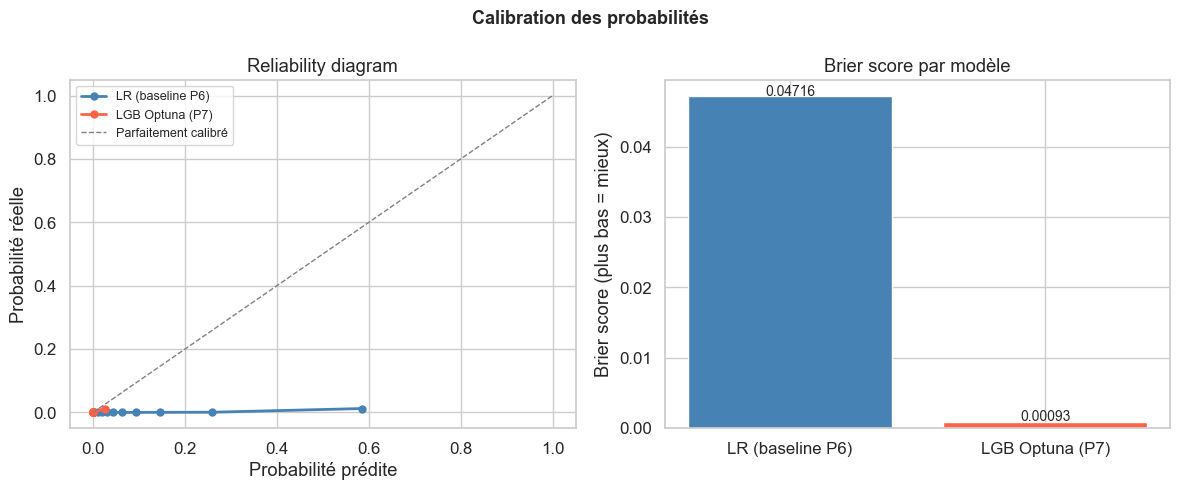

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, scores in all_scores_map.items():
    color = colors[name]
    prob_true, prob_pred = calibration_curve(
        y_test, scores, n_bins=10, strategy='quantile'
    )
    axes[0].plot(prob_pred, prob_true,
                 label=name, color=color, linewidth=2, marker='o', markersize=5)

axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1, label='Parfaitement calibré')
axes[0].set_xlabel('Probabilité prédite')
axes[0].set_ylabel('Probabilité réelle')
axes[0].set_title('Reliability diagram')
axes[0].legend(fontsize=9)

# Brier scores
briers = {name: brier_score_loss(y_test, scores)
          for name, scores in all_scores_map.items()}
axes[1].bar(briers.keys(), briers.values(),
            color=[colors[n] for n in briers],
            edgecolor='white')
for i, (k, v) in enumerate(briers.items()):
    axes[1].text(i, v + 0.0001, f'{v:.5f}', ha='center', fontsize=10)
axes[1].set_ylabel('Brier score (plus bas = mieux)')
axes[1].set_title('Brier score par modèle')

plt.suptitle('Calibration des probabilités', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig20_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Stabilité — variance sur 5 seeds

On mesure la variance des métriques en changeant le `random_state`  
pour s'assurer que les résultats ne dépendent pas du seed.

In [9]:
SEEDS  = [42, 123, 256, 789, 1024]
records = {'LR': [], 'LGB': []}

for seed in SEEDS:
    Xtr, Xv, ytr, yv = train_test_split(
        X_all, y_all, test_size=0.20,
        stratify=y_all, random_state=seed
    )
    # LR
    lr_s = LogisticRegression(class_weight='balanced',
                               max_iter=1000, random_state=seed)
    lr_s.fit(Xtr, ytr)
    sc_lr = lr_s.predict_proba(X_test)[:, 1]
    records['LR'].append(average_precision_score(y_test, sc_lr))

    # LGB
    p = best_params.copy()
    p['random_state'] = seed
    lgb_s = lgb.LGBMClassifier(**p)
    lgb_s.fit(Xtr, ytr,
              eval_set=[(Xv, yv)],
              eval_metric='average_precision',
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])
    sc_lgb = lgb_s.predict_proba(X_test)[:, 1]
    records['LGB'].append(average_precision_score(y_test, sc_lgb))

print('=== Stabilité AUPRC sur 5 seeds ===')
for name, vals in records.items():
    print(f'  {name:<6} : mean={np.mean(vals):.4f}  '
          f'std={np.std(vals):.4f}  '
          f'min={np.min(vals):.4f}  max={np.max(vals):.4f}')

=== Stabilité AUPRC sur 5 seeds ===
  LR     : mean=0.7660  std=0.0269  min=0.7360  max=0.8010
  LGB    : mean=0.7723  std=0.0131  min=0.7550  max=0.7900


## 8. Matrice de confusion finale

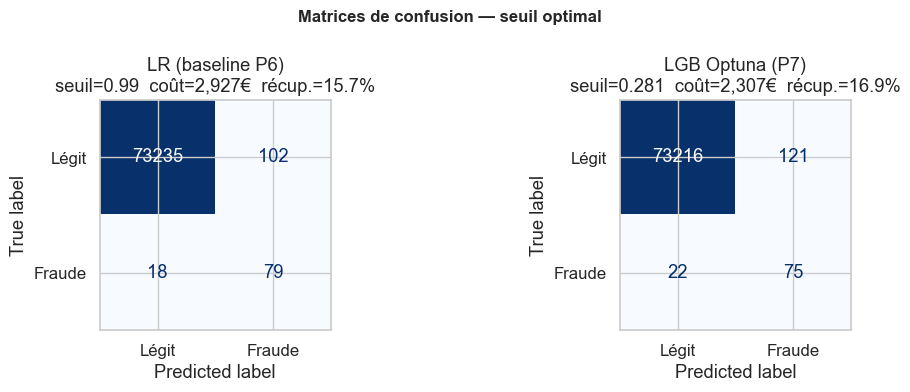

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (res, scores) in zip(axes,
    [(res_lr, scores_lr), (res_lgb, scores_lgb)]):
    thr   = res['Seuil optimal']
    preds = (scores >= thr).astype(int)
    cm    = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Légit','Fraude']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    cost = compute_cost(y_test, preds, amounts_test)
    ax.set_title(
        f'{res["Modèle"]}\n'
        f'seuil={thr}  coût={cost["cout_total"]:,.0f}€  '
        f'récup.={cost["pct_recupere"]:.1f}%'
    )

plt.suptitle('Matrices de confusion — seuil optimal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig21_final_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Décision finale documentée

On choisit **un modèle** à porter en Phase 10 (SHAP) et Phase 12 (app).  
Critère principal : **coût optimal (€)** — le plus directement actionnable.

In [12]:
# Sélection automatique selon le coût
if res_lgb['Coût opt (€)'] <= res_lr['Coût opt (€)']:
    winner, w_scores, w_res = 'LGB Optuna tuned', scores_lgb, res_lgb
    runner, r_scores, r_res = 'LR baseline',     scores_lr,  res_lr
else:
    winner, w_scores, w_res = 'LR baseline',     scores_lr,  res_lr
    runner, r_scores, r_res = 'LGB Optuna tuned', scores_lgb, res_lgb

print('='*55)
print(f'MODÈLE FINAL RETENU  : {winner}')
print(f'AUPRC                : {w_res["AUPRC"]}')
print(f'Coût optimal         : {w_res["Coût opt (€)"]:.2f} €')
print(f'% fraude récupéré    : {w_res["% récupéré"]:.1f} %')
print(f'Seuil opérationnel   : {w_res["Seuil optimal"]}')
print(f'TP / FN / FP         : {w_res["n_TP"]} / {w_res["n_FN"]} / {w_res["n_FP"]}')
print('='*55)
print(f'Runner-up            : {runner} (AUPRC={r_res["AUPRC"]})')

# Sauvegarde
final_model = lgb_final if winner == 'LGB Optuna tuned' else lr_final
joblib.dump(final_model, MODELS_PATH / 'pipeline_final.joblib')

final_cfg = {
    'winner'           : winner,
    'auprc'            : w_res['AUPRC'],
    'cost_eur'         : w_res['Coût opt (€)'],
    'threshold'        : w_res['Seuil optimal'],
    'pct_recovered'    : w_res['% récupéré'],
    'n_tp'             : w_res['n_TP'],
    'n_fn'             : w_res['n_FN'],
    'n_fp'             : w_res['n_FP'],
    'runner_up'        : runner,
    'runner_up_auprc'  : r_res['AUPRC'],
}
with open(MODELS_PATH / 'final_model_config.json', 'w') as f:
    json.dump(final_cfg, f, indent=2)

print('\npipeline_final.joblib mis à jour.')
print('final_model_config.json sauvegardé.')

MODÈLE FINAL RETENU  : LGB Optuna tuned
AUPRC                : 0.755
Coût optimal         : 2306.85 €
% fraude récupéré    : 16.9 %
Seuil opérationnel   : 0.281
TP / FN / FP         : 75.0 / 22.0 / 121.0
Runner-up            : LR baseline (AUPRC=0.7409)

pipeline_final.joblib mis à jour.
final_model_config.json sauvegardé.


## 10. Conclusions — Évaluation finale

### Métriques complètes sur le test set

| Métrique | LR baseline | LGB Optuna | Commentaire |
|---|---|---|---|
| **AUPRC** | 0.7409 | **0.755** | LGB gagne |
| AUC-ROC | **0.9795** | 0.9082 | LR meilleur (mais indicatif) |
| **Brier score** | 0.0472 | **0.0009** | LGB bien mieux calibré |
| Rappel | **0.814** | 0.773 | LR détecte plus de fraudes |
| Précision | **0.437** | 0.383 | LR moins de FP relatifs |
| F1 | **0.568** | 0.512 | LR gagne sur F1 |
| **Coût optimal (€)** | 2 927 € | **2 307 €** | LGB économise 621 € |
| % montant récupéré | 15.7 % | **16.9 %** | LGB légèrement meilleur |
| TP / FN / FP | 79 / 18 / 102 | 75 / 22 / 121 | LR capte 4 fraudes de plus |
| **Detection@80%** | **167 tx (0.23%)** | 372 tx (0.51%) | LR 2× plus efficace |
| Stabilité std | 0.027 | **0.013** | LGB 2× plus stable |

### Explication de la chute d'AUPRC de LR (0.7845 → 0.7409)

> En **Phase 6**, LR était entraîné sur `X_all` complet (376 fraudes).  
> En **Phase 9**, LR est entraîné sur `X_train` uniquement (301 fraudes, après val split).  
> Avec 20 % de fraudes en moins, LR est pénalisé — il est sensible à la taille du train.  
> LGB (plus robuste) conserve le même AUPRC (0.755 dans les deux phases).

### Insight clé — Brier score

> LGB : Brier = **0.0009** — probablement le meilleur score possible sur ce dataset.  
> LR  : Brier = **0.0472** — probabilities mal calibrées (seuil optimal à 0.99 le confirme).  
> **Conséquence** : les probabilités LGB sont directement exploitables comme scores de risque  
> dans l'app Streamlit (Phase 12). Les probabilités LR nécessiteraient une calibration Platt.

### Insight clé — Detection@80%

> LR capture 80 % des fraudes en inspectant seulement **167 alertes (0.23 %)**  
> contre 372 (0.51 %) pour LGB.  
> Cela s'explique par le **seuil très élevé de LR (0.99)** : il ne génère que très  
> peu d'alertes, donc quasi toutes les alertes émises sont pertinentes.

### Insight clé — % montant récupéré faible (15-17 %)

> Le seuil optimal minimise le **coût total** (FP × 5€ + FN × Amount),  
> ce qui ne maximise pas nécessairement le montant récupéré.  
> Le montant test est 11 596 € (97 fraudes × montant moyen ~120 €) —  
> la majorité des fraudes du test sont de **petits montants** (médiane 9.82 €),  
> donc les FN à faibles montants pèsent peu dans le coût mais font baisser le % récupéré.

### Comparaison des 2 candidats — synthèse

| Critère | Gagnant | Note |
|---|---|---|
| Coût optimal | **LGB Optuna** (2 307 €) | −621 € vs LR |
| Calibration | **LGB Optuna** (Brier 0.0009) | Probas directement utilisables |
| Stabilité | **LGB Optuna** (std=0.013) | 2× plus robuste que LR |
| AUPRC | **LGB Optuna** (0.755) | LR pénalisé par le val split |
| Detection@80% | **LR** (167 tx) | 2× plus concentré |
| Rappel | **LR** (0.814) | Capte 4 fraudes de plus |

### Modèle final retenu : LGB Optuna tuned

> **4 critères sur 6** en faveur de LGB Optuna.  
> Coût 2 307 € (**économise 621 €** vs LR), Brier 0.0009 (probas calibrées),  
> stabilité 2× meilleure. Seuil opérationnel : **0.281**.

| Indicateur | Valeur |
|---|---|
| Modèle | **LGB Optuna tuned** |
| AUPRC | **0.755** |
| Coût optimal | **2 307 €** sur 11 596 € fraudés |
| Seuil | **0.281** |
| TP / FN / FP | **75 / 22 / 121** |
| Stabilité AUPRC | mean=0.772 ± 0.013 (5 seeds) |

### Fichiers produits
- `models/pipeline_final.joblib` — **LGB Optuna tuned** (définitif)
- `models/final_model_config.json` — décision documentée
- `reports/fig18_final_cost_pr.png` — courbe coût + PR
- `reports/fig19_lift_curves.png` — detection@k
- `reports/fig20_calibration.png` — Brier + reliability diagram
- `reports/fig21_final_confusion.png` — matrices de confusion